# Data Collection - Guardian API

This notebook collects article data from the Guardian API for all 24 Russell Group Universities. The data collected here will be used in the main report (final_report.ipynb). 

To run this notebook, a Guardian API will be needed and should be stored in keys.json file (we didn't submit this because of security reasons.) A free key can be obtained from Guardian Open Platform website. 

# Setup and Imports 

In [5]:
import requests 
import json 
import time 
import pandas as pd 
import matplotlib.pyplot as plt 
import seaborn as sns

In [6]:
#loading API key 
with open('keys.json') as f:
    keys = json.load(f)
guardian_api_key = keys['guardian']['api_key'] 

# Russell Group Universities

Context: The Russell Group is a coalition of 24 research-intensive UK universities. They represent a well-defined, pre-existing grouping that dominates UK research funding and policy discourse, making them a principled choice for studying media coverage - rather than an arbitrary selection of universities. 

We use their full official names in quotes as search queries to ensure exact phrase matching and to reduce false positives. 

In [7]:
russell_group = [
    {"name": "University of Birmingham",          "query": '"University of Birmingham"'},
    {"name": "University of Bristol",             "query": '"University of Bristol"'},
    {"name": "University of Cambridge",           "query": '"University of Cambridge"'},
    {"name": "Cardiff University",                "query": '"Cardiff University"'},
    {"name": "Durham University",                 "query": '"Durham University"'},
    {"name": "University of Edinburgh",           "query": '"University of Edinburgh"'},
    {"name": "University of Exeter",              "query": '"University of Exeter"'},
    {"name": "University of Glasgow",             "query": '"University of Glasgow"'},
    {"name": "Imperial College London",           "query": '"Imperial College London"'},
    {"name": "King's College London",             "query": '"King\'s College London"'},
    {"name": "University of Leeds",               "query": '"University of Leeds"'},
    {"name": "University of Liverpool",           "query": '"University of Liverpool"'},
    {"name": "London School of Economics",        "query": '"London School of Economics"'},
    {"name": "University of Manchester",          "query": '"University of Manchester"'},
    {"name": "Newcastle University",              "query": '"Newcastle University"'},
    {"name": "University of Nottingham",          "query": '"University of Nottingham"'},
    {"name": "University of Oxford",              "query": '"University of Oxford"'},
    {"name": "Queen Mary University of London",   "query": '"Queen Mary University of London"'},
    {"name": "Queen's University Belfast",        "query": '"Queen\'s University Belfast"'},
    {"name": "University of Sheffield",           "query": '"University of Sheffield"'},
    {"name": "University of Southampton",         "query": '"University of Southampton"'},
    {"name": "University College London",         "query": '"University College London"'},
    {"name": "University of Warwick",             "query": '"University of Warwick"'},
    {"name": "University of York",               "query": '"University of York"'},
]

len(russell_group)

24

# 1. Counting Articles per University

Before collecting full article data, we first get the total article count for each university. This only requires one API call per university (no pagination needed) and will help us decide which universities to focus on. 

We will query articles from 2010 to 2024 - a 15-year window that covers major UK events including the 2010 tuition fee protests, 2012 fee rise, 2016 Brexit referendum, 2020 COVID-19 pandemic, and 2022 cost-of-living crisis. 

In [9]:
from_date = '2010-01-01' 
to_date = '2024-12-31' 

summary_rows = [] 

for uni in russell_group:
    r = requests.get(
        'https://content.guardianapis.com/search',
        params={
            'q': uni['query'],
            'api-key': guardian_api_key, 
            'from-date': from_date,
            'to-date': to_date,
            'page-size': 1 #we only need the total count
        }
    )

    if r.status_code == 200:
        total = r.json()['response']['total']
        print(f"{uni['name']}: {total} articles")
        summary_rows.append({'university': uni['name'], 'query': uni['query'], 'total_articles':total}) 
    else:
        print(f"Error {r.status_code} for {uni['name']}") 

    time.sleep(0.5) #this helps us avoid hitting the rate limit 

University of Birmingham: 1315 articles
University of Bristol: 1344 articles
University of Cambridge: 2388 articles
Cardiff University: 1431 articles
Durham University: 1196 articles
University of Edinburgh: 1662 articles
University of Exeter: 1050 articles
University of Glasgow: 817 articles
Imperial College London: 2797 articles
King's College London: 849 articles
University of Leeds: 1297 articles
University of Liverpool: 939 articles
London School of Economics: 3980 articles
University of Manchester: 1828 articles
Newcastle University: 1146 articles
University of Nottingham: 1117 articles
University of Oxford: 3170 articles
Queen Mary University of London: 1037 articles
Queen's University Belfast: 139 articles
University of Sheffield: 1211 articles
University of Southampton: 929 articles
University College London: 5227 articles
University of Warwick: 1039 articles
University of York: 1032 articles


In [10]:
summary_df = pd.DataFrame(summary_rows)
summary_df = summary_df.sort_values('total_articles', ascending=False).reset_index(drop=True)
summary_df.to_csv('data/raw/all_universities_summary.csv', index=False)
summary_df

,university,query,total_articles
0,University College London,"""University College London""",5227
1,London School of Economics,"""London School of Economics""",3980
2,University of Oxford,"""University of Oxford""",3170
3,Imperial College London,"""Imperial College London""",2797
4,University of Cambridge,"""University of Cambridge""",2388
5,University of Manchester,"""University of Manchester""",1828
6,University of Edinburgh,"""University of Edinburgh""",1662
7,Cardiff University,"""Cardiff University""",1431
8,University of Bristol,"""University of Bristol""",1344
9,University of Birmingham,"""University of Birmingham""",1315


# 2. Select the subset of universities 

We select the top 10 most-covered universities from the Guardian data. This provides a data-driven cut-off on top of our Russell Group criterion, ensuring we only analyse universities with enough articles for a meaningful time-series comparisons. 

The bar chart below shows all 24 universities ranked by article count, with the selected universities highlighted.

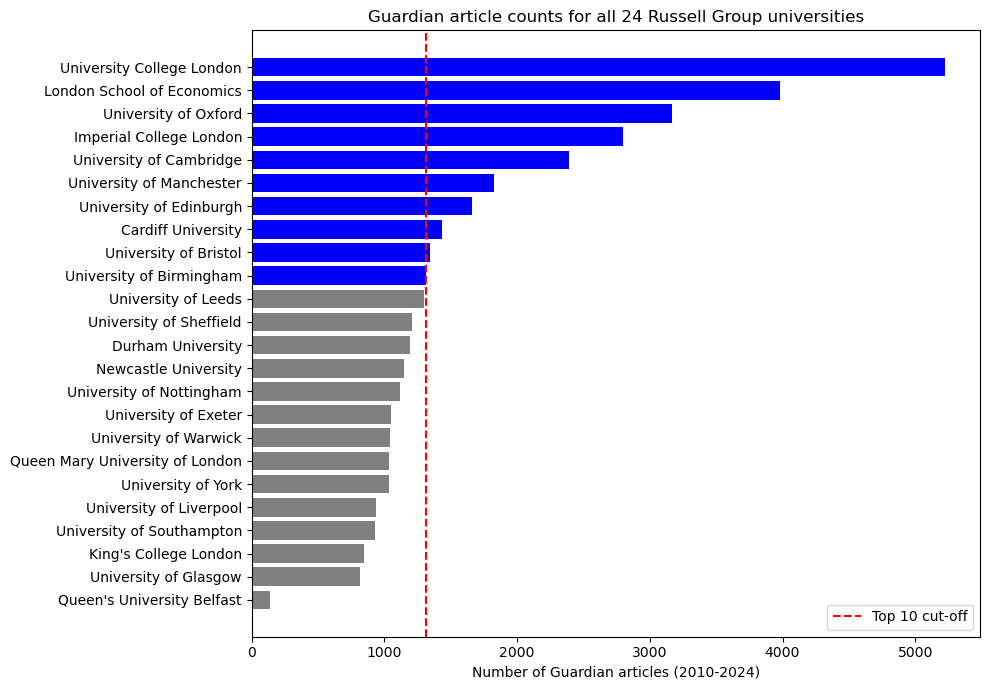

In [12]:
summary_df = pd.read_csv('data/raw/all_universities_summary.csv')
summary_df = summary_df.sort_values('total_articles', ascending=True)

TOP_N = 10

top_10 = summary_df.sort_values('total_articles', ascending=False).head(TOP_N)
cutoff = top_10['total_articles'].min()

colours = ['blue' if x >= cutoff else 'grey' for x in summary_df['total_articles']]

fig, ax = plt.subplots(figsize=(10, 7))
ax.barh(summary_df['university'], summary_df['total_articles'], color=colours)
ax.axvline(x=cutoff, color='red', linestyle='--', label=f'Top {TOP_N} cut-off')
ax.set_xlabel('Number of Guardian articles (2010-2024)')
ax.set_title('Guardian article counts for all 24 Russell Group universities')
ax.legend()
plt.tight_layout()
plt.savefig('data/raw/university_selection_chart.png')
plt.show()

There is a clear drop-off in article counts after the top 10 universities. Universities below the cut-off have too few articles for reliable time-series analysis across 15 years.

In [13]:
summary_df = pd.read_csv('data/raw/all_universities_summary.csv')
selected = summary_df.sort_values('total_articles', ascending=False).head(TOP_N)
selected_names = selected['university'].tolist()

print('Selected universities:')
print(selected_names)

Selected universities:
['University College London', 'London School of Economics', 'University of Oxford', 'Imperial College London', 'University of Cambridge', 'University of Manchester', 'University of Edinburgh', 'Cardiff University', 'University of Bristol', 'University of Birmingham']


# 3. Collect full article data for selected universities

We now collect the full article data for the selected universities using pagination. For each article we collect: publication date, section, headline, word count, and body text.

We use page-size=50 to reduce the number of API calls and include time.sleep(1) between requests to avoid rate limiting. If we hit the rate limit (HTTP 429), we wait 60 seconds before retrying.

In [15]:
#collecting articles for each selected university 

all_articles = []

for uni in russell_group:
    if uni['name'] in selected_names:
        query = uni['query']
        uni_name = uni['name']
        print('Collecting:', uni_name) 

        results = [] #storing paginated responses for this university 
        page = 1 

        #paginate through all pages of results 
        while True:
            try:
                r = requests.get(
                    'https://content.guardianapis.com/search',
                    params={
                        'q': query,
                        'api-key': guardian_api_key,
                        'order-by': 'oldest',
                        'page': page,
                        'page-size': 50,  #max 50 results per page to reduce API calls
                        'from-date': from_date,
                        'to-date': to_date,
                        'show-fields': 'wordcount,bodyText'  #request additional fields
                    }
                )

                #successful response
                if r.status_code == 200:
                    response = r.json()['response']
                    results.append(response)
                    print(f"Collected data from page {page}.")
                    #stop if we've reached the last page
                    if response['currentPage'] >= response['pages']:
                        break
                    time.sleep(1)  #wait 1 second between requests
                    page += 1
                
                #rate limit hit - wait and retry the same page
                elif r.status_code == 429:
                    print("Rate limit reached, waiting for 60 seconds")
                    time.sleep(60)
                
                #something else went wrong
                else:
                    print(f"Unexpected status code {r.status_code} on page {page}. Stopping.")
                    break
                    
            except Exception as e:
                print(f"Failed to collect data for page {page}. Error: {e}")
                break
        
        #flatten the paginated responses into a single list of articles
        for one_response in results:
            for article in one_response['results']:
                all_articles.append({
                    'university': uni_name,
                    'id': article['id'],
                    'webPublicationDate': article['webPublicationDate'],
                    'sectionId': article['sectionId'],
                    'sectionName': article['sectionName'],
                    'webTitle': article['webTitle'],
                    'wordcount': article['fields']['wordcount'],
                    'bodyText': article['fields']['bodyText']
                })
        
        print(f"Total articles so far: {len(all_articles)}")

print(f"Total articles collected: {len(all_articles)}")

Collecting: University of Birmingham
Collected data from page 1.
Collected data from page 2.
Collected data from page 3.
Collected data from page 4.
Collected data from page 5.
Collected data from page 6.
Collected data from page 7.
Collected data from page 8.
Collected data from page 9.
Collected data from page 10.
Collected data from page 11.
Collected data from page 12.
Collected data from page 13.
Collected data from page 14.
Collected data from page 15.
Collected data from page 16.
Collected data from page 17.
Collected data from page 18.
Collected data from page 19.
Collected data from page 20.
Collected data from page 21.
Collected data from page 22.
Collected data from page 23.
Collected data from page 24.
Collected data from page 25.
Collected data from page 26.
Collected data from page 27.
Total articles so far: 1315
Collecting: University of Bristol
Collected data from page 1.
Collected data from page 2.
Collected data from page 3.
Collected data from page 4.
Collected data 

In [16]:
#saving the raw data to JSON
with open('data/raw/guardian_articles.json', 'w') as f:
    json.dump(all_articles, f)

# 4: Convert to DataFrame and save as CSV 

We convert the collected data into a pandas DataFrame for easier manipulation in the main report. 

In [17]:
df = pd.DataFrame(all_articles)
df.head(3)

,university,id,webPublicationDate,sectionId,sectionName,webTitle,wordcount,bodyText
0,University of Birmingham,theguardian/2010/jan/03/simonedebeauvoir-oxfor...,2010-01-03T18:36:43Z,global,Global,Elizabeth Fallaize obituary,1007,"Elizabeth Fallaize, who has died aged 59 of mo..."
1,University of Birmingham,education/2010/jan/19/gel-curb-appetite-scient...,2010-01-19T00:05:05Z,education,Education,Food scientists develop appetite-curbing gel,839,"The season of peace, goodwill and over-indulge..."
2,University of Birmingham,science/2010/jan/25/mary-english-obituary,2010-01-25T18:38:39Z,science,Science,Mary English obituary,931,"Mary English, who has died aged 90, was one of..."


In [18]:
print(f'Shape: {df.shape}')
print(f'Universities: {df["university"].nunique()}')
print(f'Date range: {df["webPublicationDate"].min()} to {df["webPublicationDate"].max()}')
print(f'\nArticles per university:')
df.groupby('university').size().sort_values(ascending=False)

Shape: (25142, 8)
Universities: 10
Date range: 2010-01-01T14:00:01Z to 2024-12-31T17:41:43Z

Articles per university:


university
University College London     5227
London School of Economics    3980
University of Oxford          3170
Imperial College London       2797
University of Cambridge       2388
University of Manchester      1828
University of Edinburgh       1662
Cardiff University            1431
University of Bristol         1344
University of Birmingham      1315
dtype: int64

In [19]:
#check for missing values
df.isnull().sum()

university            0
id                    0
webPublicationDate    0
sectionId             0
sectionName           0
webTitle              0
wordcount             0
bodyText              0
dtype: int64

In [20]:
df.dtypes

university            object
id                    object
webPublicationDate    object
sectionId             object
sectionName           object
webTitle              object
wordcount             object
bodyText              object
dtype: object

In [21]:
#save for csv for use in the main report 
df.to_csv('data/raw/combined_raw.csv', index=False)
print('Saved to data/raw/combined_raw.csv')

Saved to data/raw/combined_raw.csv


The data is now ready for cleaning and analysis in the main report. The file data/raw/combined_raw.csv contains all articles for the selected universities, with the following columns:

- university: which university the article is about
- id: unique Guardian article ID
- webPublicationDate: publication date and time
- sectionId / sectionName: the Guardian section (e.g. politics, education, business)
- webTitle: headline of the article
- wordcount: length of the article
- bodyText: full text of the article

In [ ]:
#save without bodyText (file too large for GitHub with bodyText included)
#full data can be reproduced by re-running this notebook
df.drop(columns=['bodyText']).to_csv('data/raw/combined_raw.csv', index=False)
print('Saved without bodyText')